[Home](../../README.md)

### Data Preprocessing

This Jupyter Notebook demonstrates different processes you can apply to your data to better understand it before data wrangling. For this demonstration we will use relatively a complex real dataset that compares health measures with the speed of progress of type 2 adult onset diabetes.

#### Load the required dependencies

Load the two required dependencies:

- [Numpy](https://numpy.org/doc/stable/) is a library that enables numerical computing with Python
- [Pandas](https://pandas.pydata.org/) is library for data analysis and manipulation.
- [Matplotlib](https://matplotlib.org) a comprehensive library for creating static, animated, and interactive visualizations in Python. A customised stylesheet for the visualisations is also applied.

In [8]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')

####  Store the data as a local variable

The data frame is a Pandas object that structures your tabular data into an appropriate format. It loads the complete data in memory so it is now ready for preprocessing.

In [9]:
data_frame = pd.read_csv("spotify_data_clean.csv")

#### Data Snapshot

It is important to get a high-level look at your dataset to understand what you are working with. Printing the complete data might be impossible for large-scale datasets where the rows can be in thousands or even millions.

You can use the `head()` and `tail()` method call to inspect the first and last 5 rows of your dataset.

In [10]:
# Target = A measure of disease progression in one year
data_frame.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


####  Data Summary
 
The `info()` method call prints a summary of each column, giving you more information about the specific data types, total number of rows, null values and memory usage.

In [11]:
data_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   str    
 1   track_name          8582 non-null   str    
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   str    
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   str    
 9   album_id            8582 non-null   str    
 10  album_name          8582 non-null   str    
 11  album_release_date  8582 non-null   str    
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   str    
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), float64(1), int64(5), str(8)
memory usage: 947.2 KB


#### Statistics For Numerical Columns
 
The `describe()` method call provides basic statistical knowledge like the mean and spread of the data.

In [12]:
data_frame.describe()

,track_number,track_popularity,artist_popularity,artist_followers,album_total_tracks,track_duration_min
count,8582.000000,8582.000000,8582.000000,8.582000e+03,8582.000000,8582.000000
mean,5.772547,52.356211,69.730016,2.403472e+07,13.789443,3.492805
std,6.052792,23.816076,19.645979,3.803180e+07,11.887131,1.057970
min,1.000000,0.000000,0.000000,0.000000e+00,1.000000,0.070000
25%,1.000000,39.000000,60.000000,4.623200e+05,6.000000,2.880000
50%,4.000000,58.000000,74.000000,6.105547e+06,13.000000,3.445000
75%,9.000000,71.000000,84.000000,2.725255e+07,17.000000,3.990000
max,102.000000,99.000000,100.000000,1.455421e+08,181.000000,13.510000


#### The data columns are:

| Column | Data |
| ------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| DoB    | The patients Date of Birth recorded as D/MM/YYYY |
| DoT    | The patients date of testing records as D/MM/YYYY |
| SEX    | Patients gender --- |
| BMI    | Patients body mass index, which gives an indication of the patients body size and is calculated using their weight and height --- |
| BP     | Diastole blood pressure, which is the pressure of blood on the walls of the patient's arteries when their heart is relaxed. <80 is desirable, 80-95 is high >95 is very high. |
| TC     | Total cholesterol is a measure of the cholesterol in the patient's body. Cholesterol is essential in order for your body to continue building healthy cells; however, having high cholesterol can increase your risk of heart disease. <5.5 is desirable 5.5-6.6 is borderline, and >6.5 is undesirable |
| BGU    | Patients fasting blood glucose levels. 75-99 is desirable, and 100+ is undesirable. |
| FDR    | The number of family members in the individual's direct bloodline who have developed type 2 adult-onset diabetes. |
| Target | A quantitative measure of disease progression one year after baseline. Patients should aim towards `0` as this means the condition has not progressed further. |

#### Graphically present the data

At this early stage you are just wanting to evaluate the data, the below simple plots lets you look the data in different ways to inform your model design and data wrangling approaches.

<Axes: >

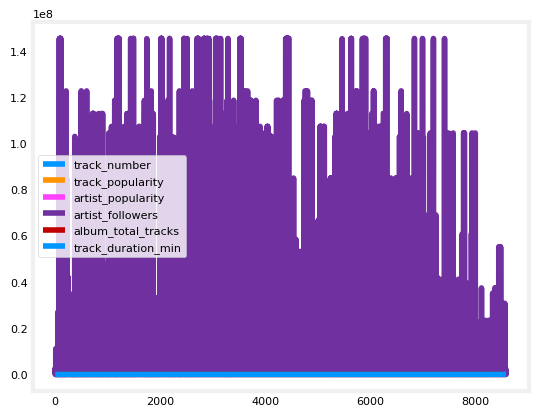

In [13]:
# plot a line graph 
data_frame.plot()

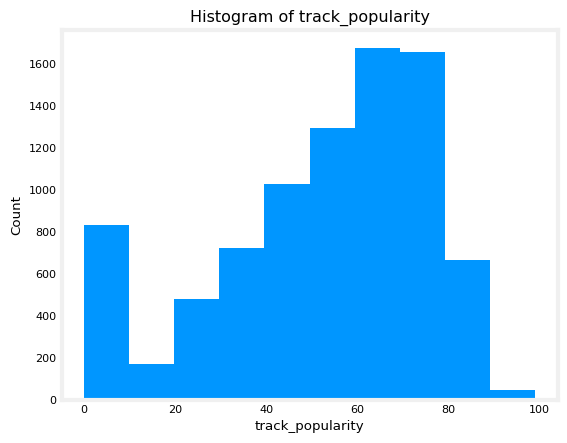

In [15]:
# Plot a histogram of a column
plt.hist(data_frame['track_popularity'])
plt.title(f"Histogram of {data_frame['track_popularity'].name}")
plt.ylabel('Count')
plt.xlabel(f'{data_frame["track_popularity"].name}')
plt.show()

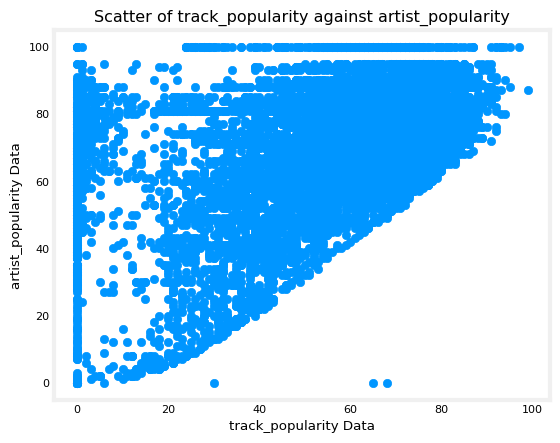

In [18]:
# Scatter plot 2 columns to see the relationship
plt.scatter(data_frame["track_popularity"], data_frame["artist_popularity"])
plt.title(
    f"Scatter of {data_frame['track_popularity'].name} against {data_frame['artist_popularity'].name}"
)
plt.ylabel(f"{data_frame['artist_popularity'].name} Data")
plt.xlabel(f"{data_frame['track_popularity'].name} Data")
plt.show()

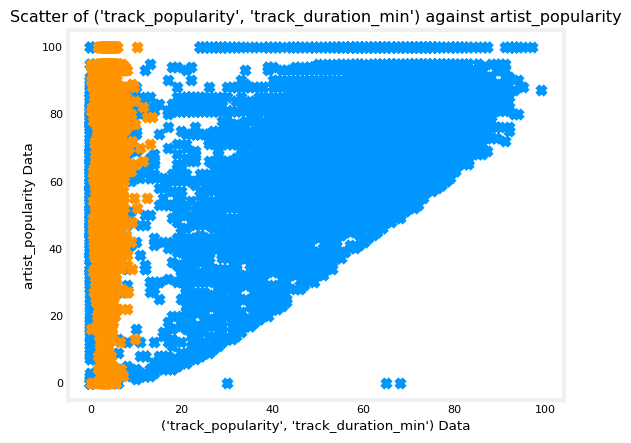

In [20]:
# Scatter plot multiples columns to see the relationship
x_plot = ['track_popularity', 'track_duration_min']
for col in x_plot:
    plt.scatter(data_frame[col], data_frame["artist_popularity"], marker="x")
plt.title(f"Scatter of {*x_plot,} against {data_frame['artist_popularity'].name}")
plt.ylabel(f"{data_frame['artist_popularity'].name} Data")
plt.xlabel(f"{*x_plot,} Data")
plt.show()

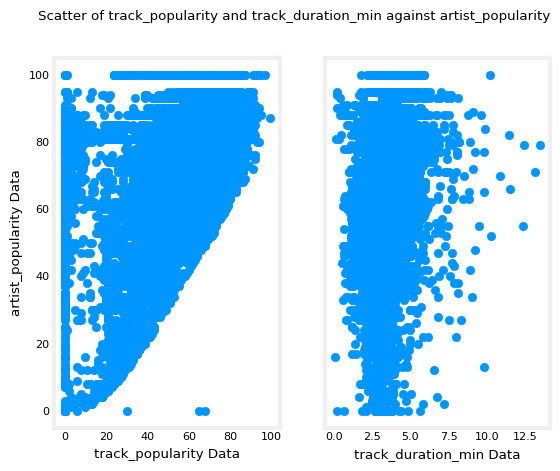

In [24]:
# Scatter plot 2 columns in separate charts with a shared y-axis
fig, (ax1, ax2) = plt.subplots(1,2, sharey=True)
plt.suptitle(f"Scatter of {data_frame['track_popularity'].name} and {data_frame['track_duration_min'].name} against {data_frame['artist_popularity'].name}")
ax1.set_ylabel(f"{data_frame['artist_popularity'].name} Data")

ax1.scatter(data_frame["track_popularity"], data_frame["artist_popularity"])
ax1.set_xlabel(f"{data_frame['track_popularity'].name} Data")

ax2.scatter(data_frame["track_duration_min"], data_frame["artist_popularity"])
ax2.set_xlabel(f"{data_frame['track_duration_min'].name} Data")

plt.show()

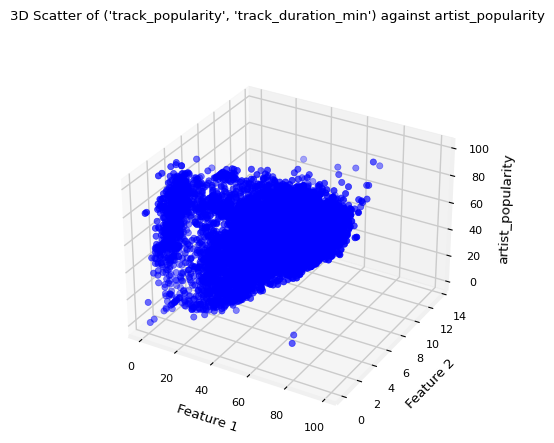

In [26]:
# 3D Scatter plot 3 columns to see the relationship

x_plot = ['track_popularity', 'track_duration_min']

fig = plt.figure()
plt.suptitle(f"3D Scatter of {*x_plot,} against {data_frame['artist_popularity'].name}")
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    data_frame[x_plot[0]],
    data_frame[x_plot[1]],
    data_frame["artist_popularity"],
    color="blue",
)

x1_range = np.linspace(data_frame[x_plot[0]].min(), data_frame[x_plot[0]].max())
x2_range = np.linspace(data_frame[x_plot[1]].min(), data_frame[x_plot[1]].max())
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)


ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel("artist_popularity")

plt.show()